In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(33)
tf.random.set_seed(33)

data = load_digits()
X, y = data.data, data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=33,
    stratify=y
)
X_train = X_train / 16.0
X_test = X_test / 16.0

In [4]:
inputs = Input(shape=(64,))

# Encoder
encoded = Dense(32, activation="relu")(inputs)
encoded = Dense(8, activation="relu")(encoded)

# Separate encoder model
encoder = Model(inputs, encoded)

# Decoder
decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(64, activation="sigmoid")(decoded)

# Complete autoencoder
autoencoder = Model(inputs, decoded)

In [5]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,744 (18.53 KB)

 Trainable params: 4,744 (18.53 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.1719 - val_loss: 0.1229
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1025 - val_loss: 0.0751
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0722 - val_loss: 0.0694
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0667 - val_loss: 0.0640
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0606 - val_loss: 0.0573
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0535 - val_loss: 0.0510
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0477 - val_loss: 0.0467
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0439 - val_loss: 0.0438
Epoch 9/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0414 - val_loss: 0.0416
Epoch 10/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0395 - val_loss: 0.0400
Epoch 11/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0379 - val_loss: 0.0387
Epoch 12/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - loss: 0.0368 - val

In [7]:
X_rec = autoencoder.predict(X_test, verbose=0)

Z_test = encoder.predict(X_test, verbose=0)

print("Latent shape:", Z_test.shape)

Latent shape: (360, 8)


In [8]:
mse = np.mean((X_test - X_rec) ** 2)

print("Reconstruction MSE:", mse)

Reconstruction MSE: 0.03144354786160019


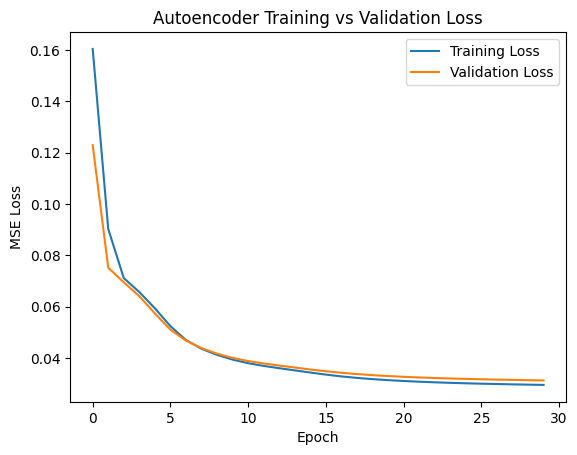

In [9]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training vs Validation Loss")
plt.legend()
plt.show()

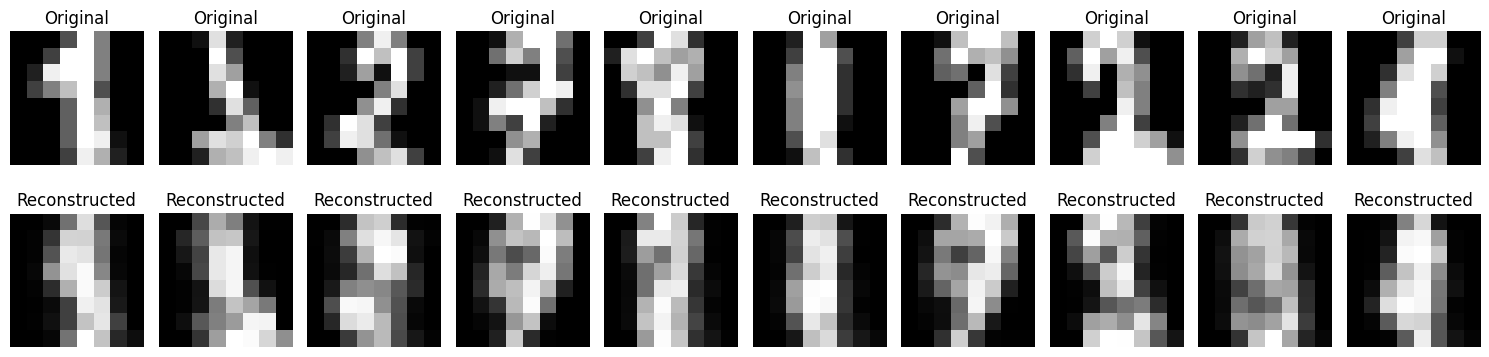

In [10]:
n = 10

plt.figure(figsize=(15, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(X_rec[i].reshape(8, 8), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

The autoencoder successfully compresses the 64-dimensional digit images into an 8-dimensional latent representation while retaining important visual information. The reconstruction MSE indicates the quality of reconstruction, with lower values representing better performance. The reconstructed images preserve the general structure of the original digits, although some information may be lost due to the restrictive bottleneck. The training and validation loss curves can be used to assess learning and identify possible overfitting.